In [17]:
import requests
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

print("Libraries loaded")

Libraries loaded


Just the imports, requests will be for "openalex"

In [18]:
def fetch_openalex_data(n_pages=5):
    works = []
    
    url = "https://api.openalex.org/works"
    params = {
        "filter": "from_publication_date:2015-01-01,to_publication_date:2018-12-31",
        "per_page": 200
    }
    
    for i in range(n_pages):
        print(f"Fetching page {i+1}...")
        response = requests.get(url, params=params)
        data = response.json()

        for work in data['results']:
            works.append({
                "title": work.get("title"),
                "abstract": work.get("abstract"),
                "year": work.get("publication_year"),
                "num_authors": len(work.get("authorships", [])),
                "num_references": len(work.get("referenced_works", [])),
                "citation_count": work.get("cited_by_count")
            })

        # pagination
        if "next_cursor" in data["meta"]:
            url = f"https://api.openalex.org/works?cursor={data['meta']['next_cursor']}"
            params = {}
        else:
            break

    return pd.DataFrame(works)


df = fetch_openalex_data(n_pages=5)
df.to_csv("papers.csv", index=False)

print("Dataset shape:", df.shape)
df.head()

Fetching page 1...
Dataset shape: (200, 6)


,title,abstract,year,num_authors,num_references,citation_count
0,Deep Residual Learning for Image Recognition,None,2016,4,81,218223
1,Global cancer statistics 2018: GLOBOCAN estima...,None,2018,6,70,87435
2,U-Net: Convolutional Networks for Biomedical I...,None,2015,3,13,87001
3,Fitting Linear Mixed-Effects Models Using <b>l...,None,2015,4,48,83453
4,Deep learning,None,2015,3,53,79873


In [19]:
df = df.dropna(subset=["title", "year", "citation_count"])

df["abstract"] = df["abstract"].fillna("")

print("Cleaned shape:", df.shape)

Cleaned shape: (200, 6)


In [20]:
# Text birleşimi
df["text"] = df["title"] + " " + df["abstract"]

# TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
X_text = vectorizer.fit_transform(df["text"])

# Sayısal featurelar
X_numeric = df[["num_authors", "num_references", "year"]].values

# Combine
from scipy.sparse import hstack
X = hstack([X_text, X_numeric]).tocsr()  # Convert to CSR format for boolean indexing

# Target (Regression)
y_reg = df["citation_count"]

# Target (Classification)
threshold = df["citation_count"].quantile(0.8)
y_clf = (df["citation_count"] > threshold).astype(int)

print("Features ready")

Features ready


In [22]:
train_mask = (df["year"] <= 2017).values
test_mask = (df["year"] == 2018).values

X_train = X[train_mask]
X_test = X[test_mask]

y_train_reg = y_reg[train_mask]
y_test_reg = y_reg[test_mask]

y_train_clf = y_clf[train_mask]
y_test_clf = y_clf[test_mask]

print("Train years:", df[train_mask]["year"].unique())
print("Test years:", df[test_mask]["year"].unique())

Train years: [2016 2015 2017]
Test years: [2018]


In [23]:
reg_model = RandomForestRegressor(n_estimators=100, n_jobs=-1)
reg_model.fit(X_train, y_train_reg)

y_pred_reg = reg_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print("RMSE:", rmse)

RMSE: 15205.699898218916


In [24]:
clf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
clf_model.fit(X_train, y_train_clf)

y_pred_clf = clf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("\nClassification Report:\n")
print(classification_report(y_test_clf, y_pred_clf))

Accuracy: 0.8157894736842105

Classification Report:

              precision    recall  f1-score   support

           0       0.82      1.00      0.90        31
           1       0.00      0.00      0.00         7

    accuracy                           0.82        38
   macro avg       0.41      0.50      0.45        38
weighted avg       0.67      0.82      0.73        38



/Users/efetokat/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/efetokat/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/efetokat/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

MAE: 8307.545263157894
RMSE: 15205.699898218916
R² Score: -0.1568945661179526


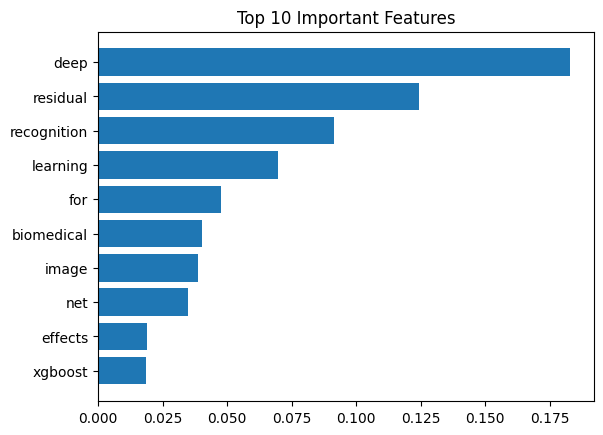

In [26]:
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


mae = mean_absolute_error(y_test_reg, y_pred_reg)
print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print("RMSE:", rmse)

r2 = r2_score(y_test_reg, y_pred_reg)
print("R² Score:", r2)

importances = reg_model.feature_importances_

# sadece numeric featureları göstermek daha anlamlı
feature_names = vectorizer.get_feature_names_out().tolist() + ["num_authors", "num_references", "year"]

indices = np.argsort(importances)[-10:]

plt.figure()
plt.title("Top 10 Important Features")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.show()